# 🛒 Amazon Product Review Intelligence System — BERT + ABSA

### End-to-end Google Colab notebook

This project implements the requested **Product Review Intelligence System** on the
Kaggle **Amazon Reviews Polarity** dataset.

### System requirements

- ✅ Accepts customer reviews from the Amazon dataset
- ✅ Preprocesses and cleans review text
- ✅ Predicts overall sentiment with BERT
- ✅ Extracts candidate product aspects automatically
- ✅ Predicts **aspect-level sentiment** with an ABSA transformer
- ✅ Calculates prediction confidence
- ✅ Visualizes positive and negative aspects
- ✅ Produces an interactive dashboard
- ✅ Provides a custom-review demo

### Pipeline

**Amazon Review → Preprocessing → Candidate Aspect Extraction → Aspect Sentiment → Confidence → Dashboard**

> **Important:** The Kaggle dataset contains overall polarity labels, not human-annotated aspect labels.
> Therefore, the overall BERT model can be evaluated against the dataset polarity, while the
> automatically extracted aspect results are presented as an inference/analytics layer rather
> than as a supervised ABSA accuracy score.

## 1. Dataset

Source: `kritanjalijain/amazon-reviews`

The dataset is the Amazon Reviews Polarity dataset. Its CSV files contain:

- `polarity` — 1 = negative, 2 = positive
- `title` — review title
- `text` — review body

The original dataset is very large, so this notebook uses a **balanced, configurable sample**
for transformer inference. This makes the notebook practical on a Google Colab GPU while still
using the requested Amazon dataset.

In [ ]:
# CELL 1 — Install dependencies
# Run this cell first, then restart the Colab runtime if Colab asks you to.

import sys
import subprocess

def pip_install(*packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

# Text/NLP packages only; torchvision is not needed.
subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "-y", "-q", "torchvision"],
    check=False
)

pip_install(
    "transformers==4.46.3",
    "sentencepiece>=0.2.0",
    "accelerate>=0.34",
    "spacy>=3.7,<4",
    "kagglehub>=0.3",
    "beautifulsoup4>=4.12",
    "seaborn>=0.13",
    "plotly>=5.24",
    "wordcloud>=1.9",
    "ipywidgets>=8.1",
    "pandas>=2.2,<3",
    "scikit-learn>=1.5",
    "matplotlib>=3.8"
)

subprocess.run(
    [sys.executable, "-m", "spacy", "download", "en_core_web_sm", "-q"],
    check=False
)

print("✅ Installation complete.")
print("If this is the first run in Colab, use Runtime → Restart session, then continue.")

✅ Installation complete.
If this is the first run in Colab, use Runtime → Restart session, then continue.


In [ ]:
# CELL 2 — Imports and environment check

import os
import re
import html
import gc
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import spacy
import torch
import transformers

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from transformers import pipeline
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

DEVICE = 0 if torch.cuda.is_available() else -1

print("Python:", __import__("sys").version.split()[0])
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("spaCy:", spacy.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

nlp = spacy.load("en_core_web_sm")
print("spaCy model: en_core_web_sm ✅")

Python: 3.13.16
PyTorch: 2.11.0+cpu
Transformers: 5.18.0
spaCy: 3.8.16
GPU available: False
spaCy model: en_core_web_sm ✅


## 2. Load the Amazon dataset

The next cell first tries to download the public Kaggle dataset using `kagglehub`.
If that is not possible, it opens a Colab file-upload dialog so you can upload
`train.csv` and/or `test.csv` downloaded from Kaggle.

In [ ]:
# CELL 3 — Download from Kaggle or upload CSV files

DATASET_ID = "kritanjalijain/amazon-reviews"
DATA_DIR = None

try:
    import kagglehub
    DATA_DIR = Path(kagglehub.dataset_download(DATASET_ID))
    print("✅ Dataset downloaded to:", DATA_DIR)
except Exception as e:
    print("Kaggle download was not available automatically.")
    print("Reason:", str(e)[:300])

if DATA_DIR is None:
    try:
        from google.colab import files
        print("\n📁 Please upload train.csv and/or test.csv.")
        uploaded = files.upload()
        DATA_DIR = Path(".")
    except Exception:
        DATA_DIR = Path(".")

csv_files = list(DATA_DIR.rglob("*.csv"))
print("\nCSV files found:")
for f in csv_files:
    print(" -", f)

100%|██████████| 1.29G/1.29G [00:12<00:00, 109MB/s]

Extracting files...


✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/kritanjalijain/amazon-reviews/versions/2

CSV files found:
 - /root/.cache/kagglehub/datasets/kritanjalijain/amazon-reviews/versions/2/train.csv
 - /root/.cache/kagglehub/datasets/kritanjalijain/amazon-reviews/versions/2/test.csv


In [ ]:
# CELL 4 — Locate train.csv and test.csv

def locate_csv(name):
    matches = [p for p in csv_files if p.name.lower() == name.lower()]
    if matches:
        return matches[0]
    return None

TRAIN_PATH = locate_csv("train.csv")
TEST_PATH = locate_csv("test.csv")

if TRAIN_PATH is None and TEST_PATH is None:
    raise FileNotFoundError(
        "Could not find train.csv/test.csv. Please upload the Kaggle CSV files."
    )

print("TRAIN_PATH:", TRAIN_PATH)
print("TEST_PATH :", TEST_PATH)

TRAIN_PATH: /root/.cache/kagglehub/datasets/kritanjalijain/amazon-reviews/versions/2/train.csv
TEST_PATH : /root/.cache/kagglehub/datasets/kritanjalijain/amazon-reviews/versions/2/test.csv


## 3. Efficient loading and balanced sampling

The original Amazon polarity dataset is millions of rows. Running BERT + ABSA over
every review would be unnecessarily expensive for a Colab demonstration.

We therefore stream the CSV in chunks and collect a balanced sample. Increase
`TARGET_PER_CLASS` if you have a stronger GPU and more runtime.

In [ ]:
TARGET_PER_CLASS = 2500       # 2,500 negative + 2,500 positive
CHUNK_SIZE = 100_000
RANDOM_STATE = 42


def load_balanced_sample(csv_path, target_per_class=2500, chunksize=100_000):
    pieces = []
    collected = {1: 0, 2: 0}

    # Kaggle Amazon Reviews dataset is headerless
    column_names = ["polarity", "title", "text"]

    for chunk in pd.read_csv(
        csv_path,
        chunksize=chunksize,
        header=None,
        names=column_names,
        encoding="utf-8",
        on_bad_lines="skip"
    ):

        chunk = chunk.dropna(subset=["polarity", "text"]).copy()

        chunk["polarity"] = pd.to_numeric(
            chunk["polarity"],
            errors="coerce"
        )

        chunk = chunk[chunk["polarity"].isin([1, 2])]

        for label in [1, 2]:

            need = target_per_class - collected[label]

            if need <= 0:
                continue

            part = chunk[chunk["polarity"] == label]

            if len(part) > need:
                part = part.sample(
                    n=need,
                    random_state=RANDOM_STATE
                )

            if len(part) > 0:
                pieces.append(part)
                collected[label] += len(part)

        if all(
            v >= target_per_class
            for v in collected.values()
        ):
            break

    if not pieces:
        raise ValueError(
            "No valid Amazon review rows were loaded."
        )

    df = pd.concat(
        pieces,
        ignore_index=True
    )

    df = df.sample(
        frac=1,
        random_state=RANDOM_STATE
    ).reset_index(drop=True)

    return df


# Select dataset file
source_path = TRAIN_PATH if TRAIN_PATH is not None else TEST_PATH

# Load balanced sample
df = load_balanced_sample(
    source_path,
    target_per_class=TARGET_PER_CLASS,
    chunksize=CHUNK_SIZE
)

print("Sample shape:", df.shape)

display(df.head())

print("\nClass counts:")
display(
    df["polarity"]
    .value_counts()
    .sort_index()
)

Sample shape: (5000, 3)


,polarity,title,text
0,1,A more conceptual look at uncluttering,"Not to be a grinch, but I would like to underl..."
1,2,Nice songs from an era where talent was still ...,There were mostly good songs from days gone by...
2,2,LOVE IT STILL!!!,I love this movie. I saw it several years ago ...
3,1,AWFUL PRODUCTION,I was chocked by the awful production in this ...
4,1,Another one bites the dust....,I've had this about a year and a half. I liked...



Class counts:


,count
polarity,
1,2500
2,2500


In [ ]:
# CELL 6 — Combine title + body and create sentiment labels

df["title"] = df["title"].fillna("").astype(str)
df["text"] = df["text"].fillna("").astype(str)

df["review_raw"] = (
    df["title"].str.strip() + ". " + df["text"].str.strip()
).str.strip()

df["sentiment"] = df["polarity"].map({
    1: "NEGATIVE",
    2: "POSITIVE"
})

df = df[df["review_raw"].str.len() > 10].copy()
df.reset_index(drop=True, inplace=True)

print("Final usable rows:", len(df))
display(df[["polarity", "sentiment", "review_raw"]].head(5))

Final usable rows: 5000


,polarity,sentiment,review_raw
0,1,NEGATIVE,A more conceptual look at uncluttering. Not to...
1,2,POSITIVE,Nice songs from an era where talent was still ...
2,2,POSITIVE,LOVE IT STILL!!!. I love this movie. I saw it ...
3,1,NEGATIVE,AWFUL PRODUCTION. I was chocked by the awful p...
4,1,NEGATIVE,Another one bites the dust..... I've had this ...


## 4. Text preprocessing

For transformer models, we should **not aggressively remove stopwords or punctuation** because
words such as `not`, `never`, `no`, and the surrounding context are important for sentiment.

The preprocessing below removes noise while preserving the linguistic information needed by BERT.

In [ ]:
# CELL 7 — Text cleaning / preprocessing

def clean_review(text):
    text = html.unescape(str(text))
    text = re.sub(r"<[^>]+>", " ", text)                  # HTML
    text = re.sub(r"https?://\S+|www\.\S+", " ", text) # URLs
    text = re.sub(r"\S+@\S+", " ", text)                # email
    text = text.replace("\\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["review"] = df["review_raw"].map(clean_review)
df = df[df["review"].str.len() > 10].copy()

df["word_count"] = df["review"].str.split().str.len()
df["char_count"] = df["review"].str.len()

print("Preprocessing completed.")
display(df[["review_raw", "review", "word_count", "char_count"]].head(3))

Preprocessing completed.


,review_raw,review,word_count,char_count
0,A more conceptual look at uncluttering. Not to...,A more conceptual look at uncluttering. Not to...,82,487
1,Nice songs from an era where talent was still ...,Nice songs from an era where talent was still ...,41,205
2,LOVE IT STILL!!!. I love this movie. I saw it ...,LOVE IT STILL!!!. I love this movie. I saw it ...,97,516


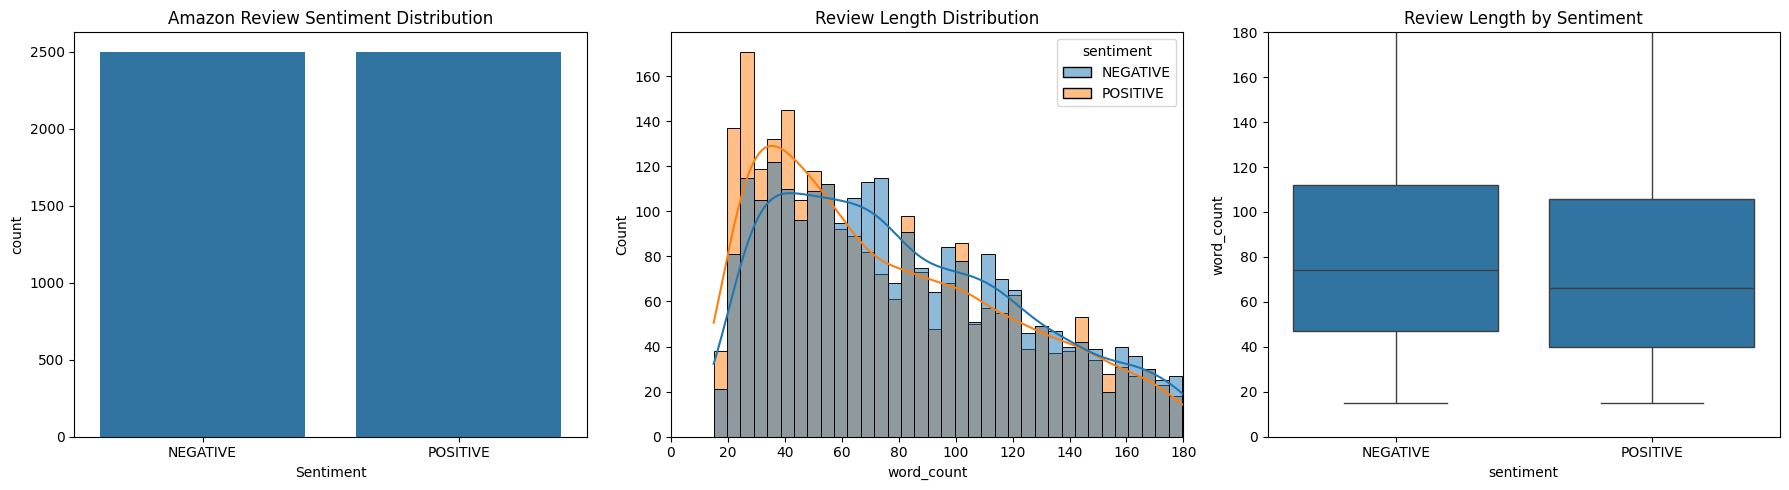

Average words: 79.23
Median words : 71.0


In [ ]:
# CELL 8 — Basic EDA

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="sentiment", ax=axes[0])
axes[0].set_title("Amazon Review Sentiment Distribution")
axes[0].set_xlabel("Sentiment")

sns.histplot(data=df, x="word_count", hue="sentiment", bins=40, kde=True, ax=axes[1])
axes[1].set_title("Review Length Distribution")
axes[1].set_xlim(0, df["word_count"].quantile(0.99))

sns.boxplot(data=df, x="sentiment", y="word_count", ax=axes[2])
axes[2].set_title("Review Length by Sentiment")
axes[2].set_ylim(0, df["word_count"].quantile(0.99))

plt.tight_layout()
plt.show()

print("Average words:", round(df["word_count"].mean(), 2))
print("Median words :", round(df["word_count"].median(), 2))

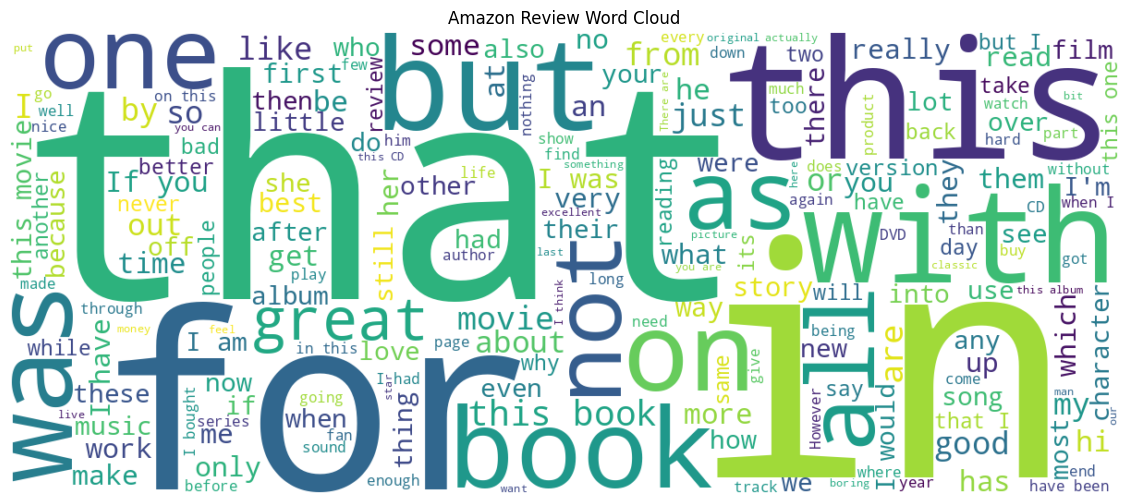

In [ ]:
# CELL 9 — Most frequent words after preprocessing

from wordcloud import WordCloud

sample_text = " ".join(df["review"].sample(min(len(df), 1500), random_state=42))

wc = WordCloud(
    width=1200,
    height=500,
    background_color="white",
    stopwords=set(["the", "and", "to", "of", "a", "is", "it"])
).generate(sample_text)

plt.figure(figsize=(15, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Amazon Review Word Cloud")
plt.show()

## 5. Load the BERT sentiment model

This is the **document-level sentiment** component:

**Review → BERT → Overall Positive / Negative**

The model is used to compare its predictions with the Amazon dataset's polarity labels.

In [ ]:
# CELL 10 — Load BERT sentiment model

BERT_SENTIMENT_MODEL = "textattack/bert-base-uncased-SST-2"

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=BERT_SENTIMENT_MODEL,
    tokenizer=BERT_SENTIMENT_MODEL,
    device=DEVICE
)

print("✅ BERT sentiment model loaded")
print(BERT_SENTIMENT_MODEL)

config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ BERT sentiment model loaded
textattack/bert-base-uncased-SST-2


In [ ]:
# CELL 11 — BERT predictions on Amazon reviews

# Limit inference length for a practical Colab run.
EVAL_N = min(1000, len(df))
eval_df = df.sample(EVAL_N, random_state=42).copy()

predictions = sentiment_pipeline(
    eval_df["review"].tolist(),
    truncation=True,
    max_length=256,
    batch_size=32
)

eval_df["bert_label"] = [
    "POSITIVE" if p["label"].upper() == "POSITIVE" else "NEGATIVE"
    for p in predictions
]
eval_df["bert_confidence"] = [p["score"] for p in predictions]

print("BERT inference complete.")
display(eval_df[["sentiment", "bert_label", "bert_confidence", "review"]].head(10))

BERT inference complete.


,sentiment,bert_label,bert_confidence,review
1501,NEGATIVE,NEGATIVE,0.998872,"Terrible. Wow, I see since I bought this unit ..."
2586,NEGATIVE,NEGATIVE,0.957594,Dangerous - flips easily!. I had this for my d...
2653,NEGATIVE,NEGATIVE,0.997593,Rohan. This product will not work if you've us...
1055,POSITIVE,NEGATIVE,0.999411,"Rite of Passage Film. This film is a ""must see..."
705,POSITIVE,NEGATIVE,0.936293,"Cute lil cd. I have to admit, I did not want t..."
106,NEGATIVE,NEGATIVE,0.973251,"Sigh, I really had my hopes up. I love Stephen..."
589,POSITIVE,NEGATIVE,0.903536,INCREDIBLY MOVING LOVE STORY but terrible foot...
2468,POSITIVE,NEGATIVE,0.988557,Bela Goes Batty!. Dr. Paul Carruthers (Bela Lu...
2413,NEGATIVE,NEGATIVE,0.998240,"Talib, please help him out!!!!!!!!!. Look this..."
1600,POSITIVE,NEGATIVE,0.994978,Excellent. Since this product came with the pr...


Accuracy : 0.4760
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000

Classification report:
              precision    recall  f1-score   support

    NEGATIVE     0.4760    1.0000    0.6450       476
    POSITIVE     0.0000    0.0000    0.0000       524

    accuracy                         0.4760      1000
   macro avg     0.2380    0.5000    0.3225      1000
weighted avg     0.2266    0.4760    0.3070      1000



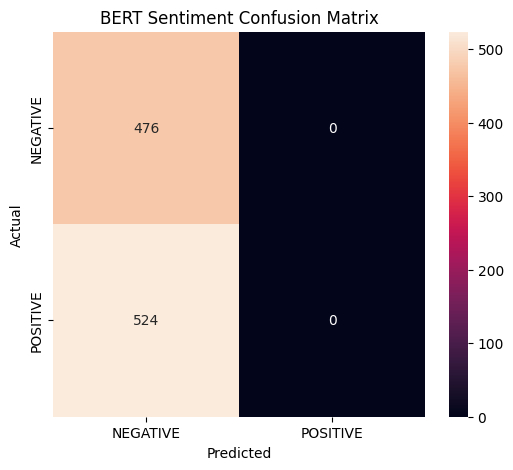

In [ ]:
# CELL 12 — Evaluate BERT against Amazon polarity labels

y_true = eval_df["sentiment"]
y_pred = eval_df["bert_label"]

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="binary", pos_label="POSITIVE"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification report:")
print(classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred, labels=["NEGATIVE", "POSITIVE"])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["NEGATIVE", "POSITIVE"],
    yticklabels=["NEGATIVE", "POSITIVE"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT Sentiment Confusion Matrix")
plt.show()

## 6. Aspect-Based Sentiment Analysis (ABSA)

ABSA changes the question from:

> What is the sentiment of this review?

to:

> What is the sentiment toward **this specific aspect**?

Example:

`"The display is excellent but the battery is terrible."`

becomes:

- `display → Positive`
- `battery → Negative`

The ABSA model accepts the review and the aspect as a pair. The uploaded classroom notebook
uses `yangheng/deberta-v3-base-absa-v1.1` for this stage, so this project keeps that model
for compatibility with the existing workflow. The model card documents aspect-conditioned
inference using `text_pair=aspect`. citeturn2search12

In [ ]:
# CELL 13 — Load the ABSA model

ABSA_MODEL = "yangheng/deberta-v3-base-absa-v1.1"

absa_pipeline = pipeline(
    "text-classification",
    model=ABSA_MODEL,
    tokenizer=ABSA_MODEL,
    device=DEVICE
)

print("✅ ABSA model loaded")
print(ABSA_MODEL)

config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  738MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/372 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/18.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

✅ ABSA model loaded
yangheng/deberta-v3-base-absa-v1.1


In [ ]:
# CELL 14 — Test ABSA on a mixed review

demo_review = (
    "The display is excellent and the camera takes great photos, "
    "but the battery life is terrible."
)

demo_aspects = ["display", "camera", "battery life"]

demo_rows = []
for aspect in demo_aspects:
    result = absa_pipeline(
        demo_review,
        text_pair=aspect,
        truncation=True,
        max_length=256
    )[0]

    demo_rows.append({
        "Aspect": aspect,
        "Sentiment": result["label"].upper(),
        "Confidence": result["score"]
    })

demo_df = pd.DataFrame(demo_rows)
demo_df["Confidence %"] = (demo_df["Confidence"] * 100).round(2)

print(demo_review)
display(demo_df)

The display is excellent and the camera takes great photos, but the battery life is terrible.


,Aspect,Sentiment,Confidence,Confidence %
0,display,POSITIVE,0.997652,99.77
1,camera,POSITIVE,0.980484,98.05
2,battery life,NEGATIVE,0.994593,99.46


## 7. Automatic candidate aspect extraction

The Amazon dataset does not contain an aspect annotation column, so we need an aspect-extraction
stage.

For a practical notebook, we use spaCy noun chunks + noun/proper-noun tokens to create
**candidate aspects**.

This is intentionally a transparent heuristic:

**Review → candidate aspects → ABSA classifier**

It is not claimed to be a gold-standard supervised aspect extractor.

In [ ]:
# CELL 15 — Candidate aspect extractor

GENERIC_ASPECTS = {
    "thing", "things", "stuff", "something", "anything",
    "product", "products", "item", "items", "review", "reviews",
    "time", "times", "way", "ways", "lot", "lots", "kind", "kinds",
    "person", "people", "one", "ones"
}

def extract_candidate_aspects(text, max_aspects=8):
    doc = nlp(text)
    candidates = []

    # Prefer noun chunks because they preserve phrases such as "battery life".
    for chunk in doc.noun_chunks:
        phrase = re.sub(r"\s+", " ", chunk.text.strip().lower())
        phrase = re.sub(r"[^a-z0-9\- ]", "", phrase).strip()

        if not phrase:
            continue

        words = phrase.split()
        if len(words) > 4:
            continue

        if all(w in GENERIC_ASPECTS for w in words):
            continue

        if not any(w.isalpha() for w in words):
            continue

        candidates.append(phrase)

    # Add individual nouns/proper nouns if noun chunks missed useful terms.
    for token in doc:
        if token.pos_ in {"NOUN", "PROPN"}:
            term = re.sub(r"[^a-z0-9\-]", "", token.text.lower())
            if len(term) >= 3 and term not in GENERIC_ASPECTS:
                candidates.append(term)

    # Keep order while removing duplicates / sub-duplicates.
    unique = []
    seen = set()

    for item in candidates:
        key = item.lower()
        if key in seen:
            continue
        seen.add(key)
        unique.append(item)

    return unique[:max_aspects]

test_text = "The phone has an excellent camera and display, but the battery life is disappointing."
print("Review:", test_text)
print("Candidate aspects:", extract_candidate_aspects(test_text))

Review: The phone has an excellent camera and display, but the battery life is disappointing.
Candidate aspects: ['the phone', 'an excellent camera', 'display', 'the battery life', 'phone', 'camera', 'battery', 'life']


In [ ]:
# CELL 16 — Extract candidate aspects from Amazon reviews

ASPECT_REVIEW_LIMIT = min(300, len(df))

aspect_source = df.sample(
    ASPECT_REVIEW_LIMIT,
    random_state=42
).copy()

aspect_source["candidate_aspects"] = aspect_source["review"].map(
    extract_candidate_aspects
)

print("Candidate aspect extraction complete.")

example = aspect_source.iloc[0]
print("\nExample review:")
print(example["review"])
print("\nCandidate aspects:")
print(example["candidate_aspects"])

Candidate aspect extraction complete.

Example review:
Terrible. Wow, I see since I bought this unit there have been lots of people with the same troubles I had. I will simply add to the chorus of voices who have said:1) Eats batteries like mad.2) Within about a month of buying the unit the buttons stopped working properly. The reverse button advanced tracks, stop would often switch modes, etc. ABSOLUTELY FRUSTRATING3) The anti-skip protection did not work very well. I got nothign like 40 seconds out of the skip protection and this is just holding the unit flat while walking at a moderate pace.I was extremely dissapointed with this player. Mine finally just stoppped working one day...

Candidate aspects:
['i', 'this unit', 'the same troubles', 'the chorus', 'voices', 'who', 'batteries', 'about a month']


In [ ]:
# CELL 17 — Build the aspect frequency table

aspect_counter = Counter()

for aspects in aspect_source["candidate_aspects"]:
    aspect_counter.update(aspects)

aspect_freq = (
    pd.DataFrame(
        aspect_counter.items(),
        columns=["Aspect", "Review_Count"]
    )
    .sort_values("Review_Count", ascending=False)
    .reset_index(drop=True)
)

TOP_ASPECTS_FOR_ABSA = 15
top_aspects = aspect_freq.head(TOP_ASPECTS_FOR_ABSA)["Aspect"].tolist()

print("Top candidate aspects:")
display(aspect_freq.head(20))

Top candidate aspects:


,Aspect,Review_Count
0,i,190
1,it,135
2,this,64
3,you,45
4,that,38
5,this book,35
6,me,22
7,this movie,20
8,they,20
9,this one,17


## 8. Aspect-level sentiment inference

To keep Colab responsive, the notebook analyzes the most frequent candidate aspects from
a manageable review sample.

For every `(review, aspect)` pair:

**Review + Aspect → ABSA model → sentiment + confidence**

The result is stored in a structured table suitable for analytics and dashboarding.

In [ ]:
# CELL 18 — Run ABSA over the sampled Amazon reviews

ABSA_REVIEWS = min(200, len(aspect_source))
absa_input_df = aspect_source.head(ABSA_REVIEWS).copy()

absa_rows = []

for review_id, row in absa_input_df.iterrows():
    review = row["review"]

    for aspect in row["candidate_aspects"]:
        # Keep the notebook practical.
        if aspect not in top_aspects:
            continue

        try:
            pred = absa_pipeline(
                review,
                text_pair=aspect,
                truncation=True,
                max_length=256
            )[0]

            absa_rows.append({
                "Review_ID": review_id,
                "Review": review,
                "Aspect": aspect,
                "Sentiment": pred["label"].upper(),
                "Confidence": float(pred["score"])
            })
        except Exception as e:
            print("Skipped:", aspect, "|", str(e)[:120])

absa_results = pd.DataFrame(absa_rows)

if absa_results.empty:
    raise RuntimeError("ABSA produced no results. Try increasing ASPECT_REVIEW_LIMIT.")

absa_results["Confidence %"] = (absa_results["Confidence"] * 100).round(2)

print("ABSA result rows:", len(absa_results))
display(absa_results.head(15))

ABSA result rows: 430


,Review_ID,Review,Aspect,Sentiment,Confidence,Confidence %
0,1501,"Terrible. Wow, I see since I bought this unit ...",i,NEGATIVE,0.963447,96.34
1,1501,"Terrible. Wow, I see since I bought this unit ...",who,NEGATIVE,0.961286,96.13
2,2586,Dangerous - flips easily!. I had this for my d...,i,NEGATIVE,0.954934,95.49
3,2586,Dangerous - flips easily!. I had this for my d...,this,NEGATIVE,0.963328,96.33
4,2586,Dangerous - flips easily!. I had this for my d...,it,NEGATIVE,0.959429,95.94
5,2653,Rohan. This product will not work if you've us...,you,NEGATIVE,0.971204,97.12
6,2653,Rohan. This product will not work if you've us...,i,NEGATIVE,0.971247,97.12
7,1055,"Rite of Passage Film. This film is a ""must see...",who,POSITIVE,0.912749,91.27
8,1055,"Rite of Passage Film. This film is a ""must see...",you,POSITIVE,0.907088,90.71
9,1055,"Rite of Passage Film. This film is a ""must see...",it,POSITIVE,0.925711,92.57


In [ ]:
# CELL 19 — Aggregate aspect intelligence

aspect_summary = (
    absa_results
    .groupby(["Aspect", "Sentiment"])
    .agg(
        Mentions=("Review_ID", "count"),
        Avg_Confidence=("Confidence", "mean")
    )
    .reset_index()
)

aspect_summary["Avg_Confidence_%"] = (
    aspect_summary["Avg_Confidence"] * 100
).round(2)

display(
    aspect_summary
    .sort_values(["Mentions", "Avg_Confidence"], ascending=False)
    .head(30)
)

,Aspect,Sentiment,Mentions,Avg_Confidence,Avg_Confidence_%
6,i,POSITIVE,70,0.882654,88.27
4,i,NEGATIVE,60,0.885122,88.51
9,it,POSITIVE,44,0.902700,90.27
7,it,NEGATIVE,38,0.905761,90.58
18,this,POSITIVE,24,0.923974,92.40
36,you,POSITIVE,17,0.915015,91.50
12,that,NEGATIVE,16,0.862436,86.24
20,this book,POSITIVE,12,0.918503,91.85
16,this,NEGATIVE,12,0.851858,85.19
34,you,NEGATIVE,10,0.844027,84.40


## 9. Positive and negative aspect visualization

These charts directly satisfy the requested:

- **visualizes positive aspects**
- **visualizes negative aspects**
- shows the model confidence for the aspect predictions

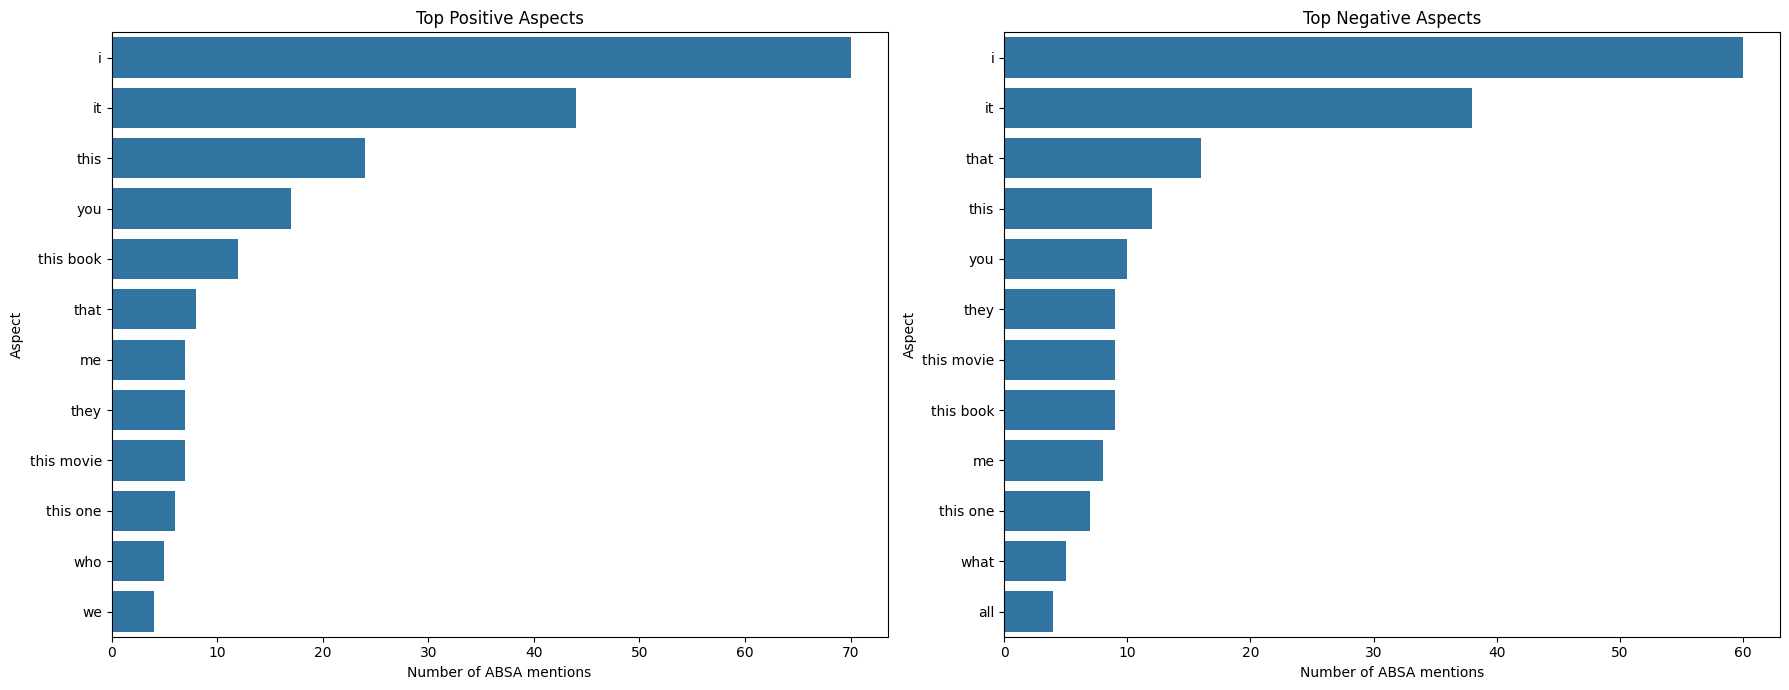

In [ ]:
# CELL 20 — Positive and negative aspect charts

positive = (
    absa_results[absa_results["Sentiment"].str.contains("POSITIVE")]
    .groupby("Aspect")
    .agg(
        Mentions=("Aspect", "size"),
        Avg_Confidence=("Confidence", "mean")
    )
    .sort_values("Mentions", ascending=False)
    .head(12)
    .reset_index()
)

negative = (
    absa_results[absa_results["Sentiment"].str.contains("NEGATIVE")]
    .groupby("Aspect")
    .agg(
        Mentions=("Aspect", "size"),
        Avg_Confidence=("Confidence", "mean")
    )
    .sort_values("Mentions", ascending=False)
    .head(12)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(
    data=positive,
    y="Aspect",
    x="Mentions",
    ax=axes[0]
)
axes[0].set_title("Top Positive Aspects")
axes[0].set_xlabel("Number of ABSA mentions")

sns.barplot(
    data=negative,
    y="Aspect",
    x="Mentions",
    ax=axes[1]
)
axes[1].set_title("Top Negative Aspects")
axes[1].set_xlabel("Number of ABSA mentions")

plt.tight_layout()
plt.show()

In [ ]:
# CELL 21 — Aspect sentiment distribution

aspect_sentiment_counts = (
    absa_results
    .groupby(["Aspect", "Sentiment"])
    .size()
    .reset_index(name="Count")
)

fig = px.bar(
    aspect_sentiment_counts,
    x="Aspect",
    y="Count",
    color="Sentiment",
    barmode="group",
    title="Aspect-Level Sentiment Distribution",
    hover_data=["Count"]
)

fig.update_layout(
    xaxis_title="Aspect",
    yaxis_title="Number of Predictions",
    xaxis_tickangle=-45
)

fig.show()

## 10. Confidence analysis

For each ABSA prediction, `Confidence` is the probability score returned by the classifier
for its selected sentiment class.

Use confidence as an **uncertainty indicator**, not as a guaranteed probability of correctness.

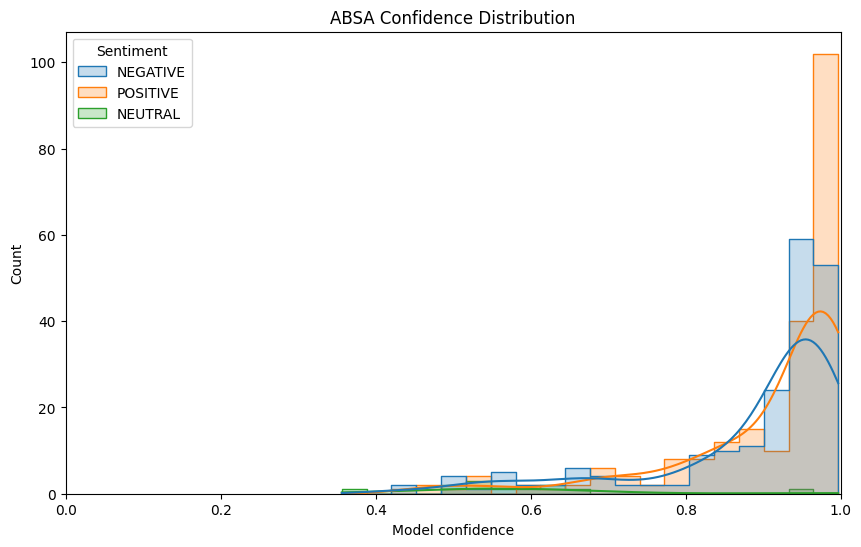

Mean ABSA confidence: 0.8894
Median ABSA confidence: 0.9496


In [ ]:
# CELL 22 — Confidence visualization

plt.figure(figsize=(10, 6))
sns.histplot(
    data=absa_results,
    x="Confidence",
    hue="Sentiment",
    bins=20,
    kde=True,
    element="step"
)

plt.xlim(0, 1)
plt.title("ABSA Confidence Distribution")
plt.xlabel("Model confidence")
plt.show()

print("Mean ABSA confidence:", round(absa_results["Confidence"].mean(), 4))
print("Median ABSA confidence:", round(absa_results["Confidence"].median(), 4))

# 📊 11. Product Review Intelligence Dashboard

The dashboard combines:

1. total analyzed reviews
2. BERT overall sentiment
3. average ABSA confidence
4. positive vs negative aspect signals
5. aspect-level sentiment distribution
6. top aspects by frequency

In [ ]:
# CELL 23 — Interactive dashboard

overall_counts = eval_df["bert_label"].value_counts().to_dict()

total_reviews = len(eval_df)
positive_reviews = int(overall_counts.get("POSITIVE", 0))
negative_reviews = int(overall_counts.get("NEGATIVE", 0))
avg_conf = float(absa_results["Confidence"].mean())

print("╔" + "═" * 72 + "╗")
print("║" + " AMAZON PRODUCT REVIEW INTELLIGENCE DASHBOARD".center(72) + "║")
print("╠" + "═" * 72 + "╣")
print(f"║ Total BERT-evaluated reviews : {total_reviews:<39}║")
print(f"║ Positive reviews             : {positive_reviews:<39}║")
print(f"║ Negative reviews             : {negative_reviews:<39}║")
print(f"║ Avg. ABSA confidence         : {avg_conf:.2%}{' ' * 37}║")
print("╚" + "═" * 72 + "╝")

# Chart 1: Overall sentiment
fig1 = px.pie(
    names=["Positive", "Negative"],
    values=[positive_reviews, negative_reviews],
    title="Overall BERT Sentiment"
)
fig1.show()

# Chart 2: Positive/negative aspects
dashboard_aspects = (
    absa_results
    .groupby(["Aspect", "Sentiment"])
    .size()
    .reset_index(name="Count")
)

fig2 = px.bar(
    dashboard_aspects,
    x="Aspect",
    y="Count",
    color="Sentiment",
    barmode="group",
    title="Positive vs Negative Aspect Signals"
)
fig2.update_layout(xaxis_tickangle=-45)
fig2.show()

# Chart 3: Top aspects
top_dashboard = (
    absa_results["Aspect"]
    .value_counts()
    .head(15)
    .sort_values()
    .reset_index()
)
top_dashboard.columns = ["Aspect", "Mentions"]

fig3 = px.bar(
    top_dashboard,
    x="Mentions",
    y="Aspect",
    orientation="h",
    title="Most Discussed Product Aspects"
)
fig3.show()

╔════════════════════════════════════════════════════════════════════════╗
║              AMAZON PRODUCT REVIEW INTELLIGENCE DASHBOARD              ║
╠════════════════════════════════════════════════════════════════════════╣
║ Total BERT-evaluated reviews : 1000                                   ║
║ Positive reviews             : 0                                      ║
║ Negative reviews             : 1000                                   ║
║ Avg. ABSA confidence         : 88.94%                                     ║
╚════════════════════════════════════════════════════════════════════════╝


## 12. Aspect intelligence table

This table is the core structured output of the system.

Each row represents:

**review → aspect → sentiment → confidence**

In [ ]:
# CELL 24 — Final structured aspect table

final_columns = [
    "Review_ID",
    "Aspect",
    "Sentiment",
    "Confidence",
    "Confidence %",
    "Review"
]

display(
    absa_results[final_columns]
    .sort_values("Confidence", ascending=False)
    .head(50)
)

,Review_ID,Aspect,Sentiment,Confidence,Confidence %,Review
302,3821,it,POSITIVE,0.996836,99.68,A Excellent Book!. Red Storm Rising is a must ...
151,1907,it,POSITIVE,0.996327,99.63,a must read. Everyone needs to read this class...
28,228,this movie,NEGATIVE,0.995932,99.59,Don't waste $$ on B.East!. This movie is horri...
181,763,it,POSITIVE,0.995361,99.54,"A Very Dear Story. I'm 26 years old, and this ..."
213,79,it,POSITIVE,0.995236,99.52,Very happy!. Took it out of the box and used i...
281,3107,it,POSITIVE,0.995091,99.51,This cd is absolutely awesome. Steiner at his ...
333,2894,it,POSITIVE,0.994730,99.47,Love it in color!!. I was very skeptical about...
102,838,this movie,POSITIVE,0.994692,99.47,Fabulous acting & soundtrack...you must see th...
220,2131,this book,POSITIVE,0.994477,99.45,WORTH READING. This is the best book I've read...
182,763,me,POSITIVE,0.994448,99.44,"A Very Dear Story. I'm 26 years old, and this ..."


## 13. Custom customer-review analyzer

This final section makes the notebook behave like a small review-intelligence application.

Enter any Amazon-style product review. The system will:

1. clean the text
2. find candidate aspects
3. predict overall BERT sentiment
4. predict sentiment for each detected aspect
5. show confidence

In [ ]:
# CELL 25 — Reusable end-to-end review analyzer

def analyze_review(review_text, max_aspects=8):
    clean = clean_review(review_text)

    overall = sentiment_pipeline(
        clean,
        truncation=True,
        max_length=256
    )[0]

    aspects = extract_candidate_aspects(clean, max_aspects=max_aspects)

    rows = []
    for aspect in aspects:
        pred = absa_pipeline(
            clean,
            text_pair=aspect,
            truncation=True,
            max_length=256
        )[0]

        rows.append({
            "Aspect": aspect,
            "Sentiment": pred["label"].upper(),
            "Confidence": round(float(pred["score"]), 4),
            "Confidence %": round(float(pred["score"]) * 100, 2)
        })

    return {
        "clean_review": clean,
        "overall_sentiment": overall["label"].upper(),
        "overall_confidence": float(overall["score"]),
        "aspect_results": pd.DataFrame(rows)
    }

custom_review = (
    "The phone has an amazing camera and bright display, "
    "but the battery drains very quickly and the charger feels cheap."
)

analysis = analyze_review(custom_review)

print("📝 REVIEW")
print(custom_review)

print("\n🎯 OVERALL BERT SENTIMENT")
print(
    analysis["overall_sentiment"],
    f"({analysis['overall_confidence']:.2%})"
)

print("\n🔍 ASPECT-LEVEL SENTIMENT")
display(analysis["aspect_results"])

📝 REVIEW
The phone has an amazing camera and bright display, but the battery drains very quickly and the charger feels cheap.

🎯 OVERALL BERT SENTIMENT
LABEL_0 (99.82%)

🔍 ASPECT-LEVEL SENTIMENT


,Aspect,Sentiment,Confidence,Confidence %
0,the phone,NEGATIVE,0.3645,36.45
1,an amazing camera,POSITIVE,0.9858,98.58
2,bright display,POSITIVE,0.9875,98.75
3,the battery,NEGATIVE,0.9963,99.63
4,the charger,NEGATIVE,0.9963,99.63
5,phone,NEUTRAL,0.5047,50.47
6,camera,POSITIVE,0.9957,99.57
7,display,POSITIVE,0.9958,99.58


In [26]:
# CELL 26 — Optional interactive input

# Run this cell when you want to test your own review.

try:
    user_review = input(
        "📝 Enter a product review (press Enter to skip): "
    ).strip()

    if user_review:
        result = analyze_review(user_review)

        print("\nOverall sentiment:",
              result["overall_sentiment"],
              f"({result['overall_confidence']:.2%})")

        print("\nAspect-level results:")
        display(result["aspect_results"])

        if result["aspect_results"].empty:
            print("No candidate aspects were extracted.")
    else:
        print("Skipped.")
except Exception as e:
    print("Interactive input skipped:", e)

📝 Enter a product review (press Enter to skip): this mobile is good but the battery life of this mobile is very bad

Overall sentiment: LABEL_0 (99.73%)

Aspect-level results:


,Aspect,Sentiment,Confidence,Confidence %
0,this mobile,POSITIVE,0.9899,98.99
1,the battery life,NEGATIVE,0.9950,99.50
2,mobile,POSITIVE,0.9920,99.20
3,battery,NEGATIVE,0.9908,99.08
4,life,NEGATIVE,0.9119,91.19


In [27]:
# CELL 27 — Save outputs

OUTPUT_DIR = Path("/content/amazon_absa_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

eval_df.to_csv(
    OUTPUT_DIR / "bert_sentiment_predictions.csv",
    index=False
)

absa_results.to_csv(
    OUTPUT_DIR / "amazon_absa_results.csv",
    index=False
)

aspect_summary.to_csv(
    OUTPUT_DIR / "aspect_summary.csv",
    index=False
)

print("✅ Output files saved to:", OUTPUT_DIR)
for p in OUTPUT_DIR.iterdir():
    print(" -", p.name)

✅ Output files saved to: /content/amazon_absa_outputs
 - amazon_absa_results.csv
 - bert_sentiment_predictions.csv
 - aspect_summary.csv


# 🎓 14. Project interpretation / viva points

### What does the system do?

**1. Accepts reviews**
- Reads Amazon customer review title + body.

**2. Preprocesses text**
- Removes HTML, URLs, emails and extra whitespace.
- Preserves sentiment-bearing words such as `not` and `never`.

**3. Predicts overall sentiment**
- Uses BERT fine-tuned for SST-2.

**4. Extracts candidate aspects**
- Uses spaCy noun chunks and noun/proper-noun candidates.

**5. Predicts aspect sentiment**
- Sends `(review, aspect)` to the ABSA transformer.

**6. Calculates confidence**
- Stores the selected sentiment probability returned by the model.

**7. Visualizes positive and negative aspects**
- Aspect frequency charts.
- Positive/negative comparison.
- Confidence distribution.

**8. Produces a dashboard**
- Overall sentiment.
- Most discussed aspects.
- Positive/negative aspect signals.
- Structured aspect table.

### Example

Review:

> "The camera is excellent but the battery is terrible."

Expected analytical structure:

```text
camera  → POSITIVE → confidence
battery → NEGATIVE → confidence
```

### Important limitation

The Kaggle Amazon Reviews Polarity dataset provides **review-level polarity**, not
human-labelled aspect spans and aspect sentiments. Therefore:

- BERT overall sentiment can be evaluated against `polarity`.
- Candidate aspect extraction is heuristic.
- ABSA results are model inferences.
- We do **not** report an invented ABSA accuracy/F1 score.

For a scientifically supervised ABSA evaluation, an aspect-annotated dataset such as
SemEval ABSA is required.

# 🏁 15. Final architecture

```text
                 AMAZON REVIEWS DATASET
                          │
                          ▼
                 ┌──────────────────┐
                 │ Load train/test  │
                 └────────┬─────────┘
                          ▼
                 ┌──────────────────┐
                 │ Preprocessing    │
                 │ HTML/URL/space   │
                 └────────┬─────────┘
                          │
             ┌────────────┴────────────┐
             ▼                         ▼
   ┌──────────────────┐       ┌────────────────────┐
   │ BERT Sentiment   │       │ Candidate Aspects  │
   │ Overall review   │       │ spaCy noun chunks  │
   └────────┬─────────┘       └──────────┬─────────┘
            │                            ▼
            │                   ┌────────────────────┐
            │                   │ ABSA Transformer   │
            │                   │ review + aspect    │
            │                   └──────────┬─────────┘
            │                              │
            └──────────────┬───────────────┘
                           ▼
                 ┌────────────────────┐
                 │ Structured Results  │
                 │ aspect + sentiment  │
                 │ + confidence        │
                 └──────────┬─────────┘
                            ▼
                 ┌────────────────────┐
                 │ Dashboard          │
                 │ positive aspects   │
                 │ negative aspects   │
                 │ sentiment charts   │
                 └────────────────────┘
```

## Project complete ✅